In [2]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sqlalchemy import create_engine
from dotenv import load_dotenv
from sklearn.ensemble import IsolationForest
from scipy import stats

sns.set(style="whitegrid")
%matplotlib inline

load_dotenv()
engine = create_engine(os.getenv("DATABASE_URL"))

pl = pd.read_sql("SELECT * FROM fact_profit_loss", engine)
bs = pd.read_sql("SELECT * FROM fact_balance_sheet", engine)
cf = pd.read_sql("SELECT * FROM fact_cash_flow", engine)

In [3]:
pl_y = pl[~pl["year_label"].str.contains("TTM", case=False, na=False)].copy()
bs_y = bs[~bs["year_label"].str.contains("TTM", case=False, na=False)].copy()
cf_y = cf[~cf["year_label"].str.contains("TTM", case=False, na=False)].copy()

In [4]:
records = []

def zscore_anomalies(df, symbol, metric):
    g = df[df["symbol"] == symbol].copy()
    if g[metric].notna().sum() < 3:
        return
    z = stats.zscore(g[metric].astype(float), nan_policy="omit")
    g["z"] = z
    # mark |z| > 2.5 as anomaly
    out = g[abs(g["z"]) > 2.5].copy()
    for _, r in out.iterrows():
        records.append({
            "symbol": symbol,
            "year_label": r["year_label"],
            "metric": metric,
            "value": r[metric],
            "zscore": r["z"],
            "method": "zscore"
        })

for sym in pl_y["symbol"].unique():
    zscore_anomalies(pl_y, sym, "sales")
    zscore_anomalies(pl_y, sym, "net_profit")

for sym in bs_y["symbol"].unique():
    zscore_anomalies(bs_y, sym, "borrowings")

for sym in pl_y["symbol"].unique():
    if "operating_profit" in pl_y.columns:
        zscore_anomalies(pl_y, sym, "operating_profit")

z_anoms = pd.DataFrame(records)
z_anoms.head()

,symbol,year_label,metric,value,zscore,method
0,ADANIENT,Mar 2023,sales,127540.0,2.558873,zscore
1,ADANIPOWER,Mar 2024,net_profit,20829.0,2.706289,zscore
2,AXISBANK,Mar 2024,net_profit,24861.0,2.805724,zscore
3,BAJAJHLDNG,Mar 2024,sales,1702.0,3.129742,zscore
4,BAJAJHLDNG,Mar 2024,net_profit,7365.0,2.679669,zscore


In [5]:
panel = pl_y.merge(
    bs_y[["symbol","year_label","borrowings"]],
    on=["symbol","year_label"], how="left"
).merge(
    cf_y[["symbol","year_label","operating_activity"]],
    on=["symbol","year_label"], how="left"
)

features = panel[["sales","net_profit","borrowings","operating_profit","operating_activity"]].copy()
features = features.fillna(0).astype(float)

In [6]:
iso = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)
iso.fit(features)

panel["iforest_score"] = iso.decision_function(features)
panel["iforest_flag"] = iso.predict(features)  # -1 = anomaly, 1 = normal

iso_anoms = panel[panel["iforest_flag"] == -1].copy()
iso_anoms["metric"] = "multi_feature"
iso_anoms["method"] = "isolation_forest"
iso_anoms = iso_anoms[["symbol","year_label","metric","iforest_score","method"]]
iso_anoms.head()

,symbol,year_label,metric,iforest_score,method
180,AXISBANK,Mar 2024,multi_feature,-0.057948,isolation_forest
192,BAJAJFINSV,Mar 2024,multi_feature,-0.009684,isolation_forest
220,BANKBARODA,Mar 2018,multi_feature,-0.011202,isolation_forest
225,BANKBARODA,Mar 2023,multi_feature,-0.055648,isolation_forest
226,BANKBARODA,Mar 2024,multi_feature,-0.058214,isolation_forest


In [7]:
all_anoms = pd.concat([
    z_anoms,
    iso_anoms.rename(columns={"iforest_score":"score"})
], ignore_index=True)

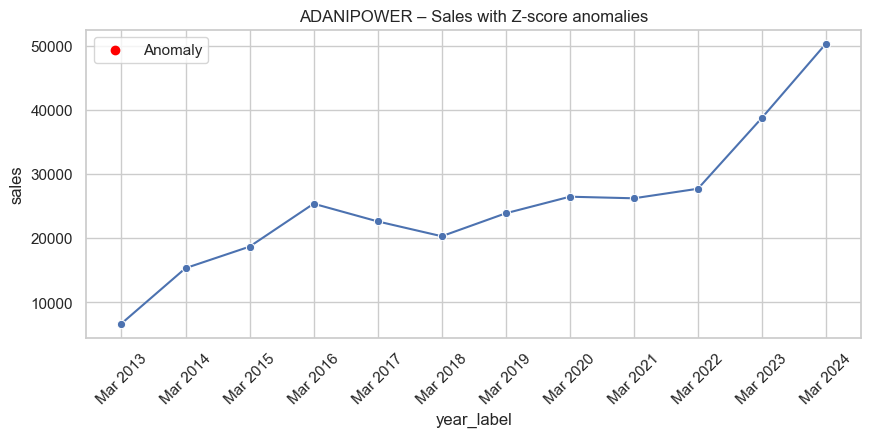

In [8]:
sym = "ADANIPOWER"  # change to test others
sym_pl = pl_y[pl_y["symbol"] == sym].sort_values("year_label")

plt.figure(figsize=(10,4))
sns.lineplot(data=sym_pl, x="year_label", y="sales", marker="o")
an = all_anoms[(all_anoms["symbol"]==sym) & (all_anoms["metric"]=="sales")]
plt.scatter(an["year_label"], an["value"], color="red", label="Anomaly")
plt.title(f"{sym} – Sales with Z-score anomalies")
plt.legend()
plt.xticks(rotation=45)
plt.show()

In [9]:
all_anoms[(all_anoms["symbol"].isin(["ADANIPOWER","ADANIENT","ADANIGREEN"]))
          & all_anoms["year_label"].isin(["Mar 2022","Mar 2023"])]

,symbol,year_label,metric,value,zscore,method,score
0,ADANIENT,Mar 2023,sales,127540.0,2.558873,zscore,NaN


In [10]:
out_cols = ["symbol","year_label","metric","method"]
all_anoms["created_at"] = pd.Timestamp.utcnow()

out_path = "../data/clean/fact_anomaly_flags.csv"
all_anoms.to_csv(out_path, index=False)
out_path

'../data/clean/fact_anomaly_flags.csv'